# MRI Fourier Demo: direct **k-space** control (100 × 100)

* `%matplotlib widget` backend (needs `pip install ipympl`)
* Dashed square = 22 cm × 22 cm field-of-view (FOV)
* **Float sliders move in real k-space units (m⁻¹)**
* ▶ animates full Cartesian acquisition


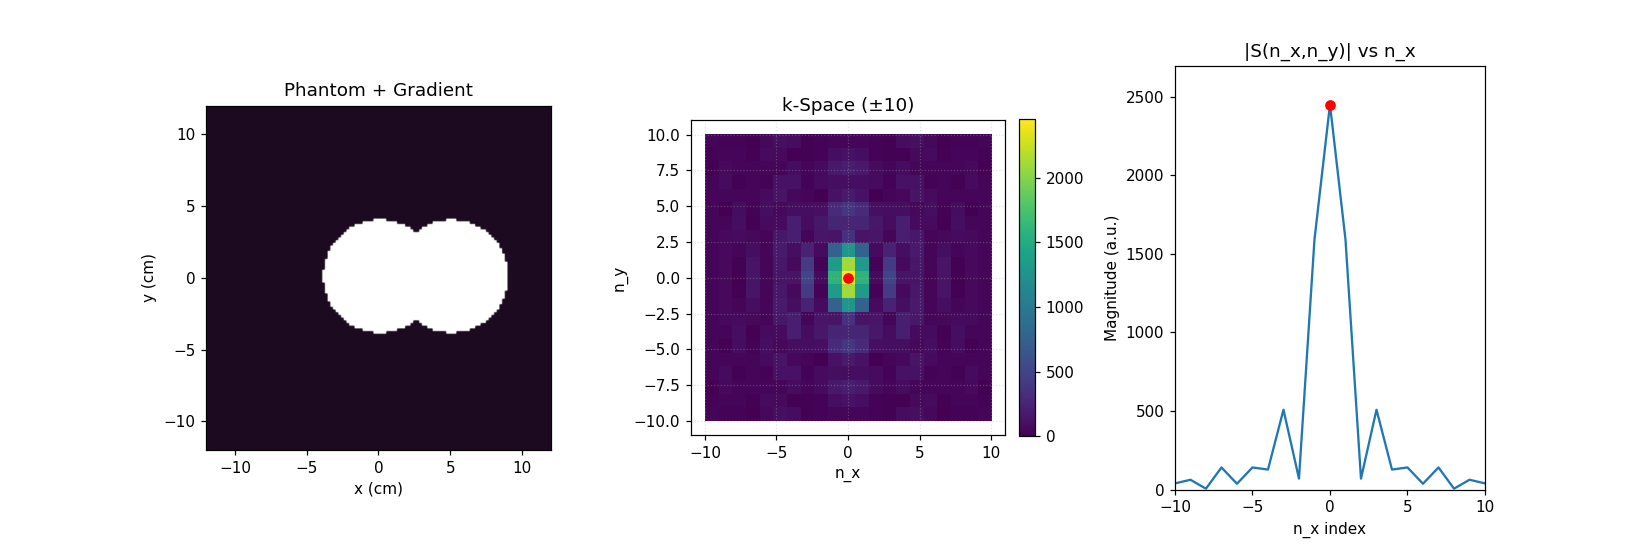

In [2]:
# ---------- Imports ----------
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as wd
from ipywidgets import FloatSlider, IntSlider, VBox
from IPython.display import display

plt.close("all")
%matplotlib widget

# ---------- Parameters ----------
FOV = 0.24          # metres (24 cm)
VOX_SIZE = 0.002    # metres (2 mm)
K_LIM  = 10         # ±k‑space indices
SHIFT_LIM = 0.05    # ±5 cm translation range
SCL_MIN, SCL_MAX = 0.5, 1.5  # squash/stretch factors

next_pow2 = lambda x: 1 << (x - 1).bit_length()

# ---------- Globals ----------
fig = None
phase_im = fill_im = kpt = kmap = line_sig = dot_sig = None

# ------------------------------------------------------------------
#                           INITIALISE
# ------------------------------------------------------------------

def initialise(*_):
    global N, ctr, dk, X, Y
    global fig, phase_im, fill_im, kpt, kmap, line_sig, dot_sig, sliders

    N = next_pow2(int(np.ceil(FOV / VOX_SIZE)))
    ctr = N // 2
    dk  = 1.0 / FOV
    coords = np.linspace(-FOV/2, FOV/2, N, endpoint=False)
    X, Y = np.meshgrid(coords, coords)

    if fig is None:
        fig = plt.figure(figsize=(15, 5), dpi=110, facecolor="white")
    else:
        fig.clf(); fig.set_size_inches(15, 5); fig.set_dpi(110); fig.set_facecolor("white")

    gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.9], wspace=0.42)
    ax_img = fig.add_subplot(gs[0, 0], facecolor="black")
    ax_ksp = fig.add_subplot(gs[0, 1])
    ax_sig = fig.add_subplot(gs[0, 2])

    extent_cm = [-FOV/2*100, FOV/2*100, -FOV/2*100, FOV/2*100]

    # Layer 1: phase gradient (under phantoms)
    phase_im = ax_img.imshow(np.zeros((N, N)), cmap="twilight", alpha=0.6,
                             origin="lower", vmin=-np.pi, vmax=np.pi, extent=extent_cm, zorder=1)
    # Layer 2: opaque white fill for phantoms
    fill_im  = ax_img.imshow(np.zeros((N, N, 4)), origin="lower", extent=extent_cm, zorder=2)

    ax_img.set_title("Phantom + Gradient", color="black")
    ax_img.set_xlabel("x (cm)", color="black"); ax_img.set_ylabel("y (cm)", color="black")
    ax_img.tick_params(colors="black")

    # k‑space panel --------------------------------------------------
    kmap = ax_ksp.imshow(np.zeros((2*K_LIM+1, 2*K_LIM+1)), cmap="viridis",
                         origin="lower", extent=[-K_LIM, K_LIM, -K_LIM, K_LIM])
    fig.colorbar(kmap, ax=ax_ksp, fraction=0.046, pad=0.04).set_label("")
    ax_ksp.set_xlim(-K_LIM-1, K_LIM+1); ax_ksp.set_ylim(-K_LIM-1, K_LIM+1)
    ax_ksp.set_aspect("equal"); ax_ksp.grid(True, linestyle=":", alpha=0.35)
    ax_ksp.set_title(f"k‑Space (±{K_LIM})")
    ax_ksp.set_xlabel("n_x"); ax_ksp.set_ylabel("n_y")
    kpt, = ax_ksp.plot(0, 0, "ro", ms=6, zorder=2)

    # Magnitude profile ---------------------------------------------
    ax_sig.set_xlim(-K_LIM, K_LIM)
    ax_sig.set_title("|S(n_x,n_y)| vs n_x")
    ax_sig.set_xlabel("n_x index"); ax_sig.set_ylabel("Magnitude (a.u.)")
    x_view = np.arange(-K_LIM, K_LIM+1)
    line_sig, = ax_sig.plot(x_view, np.zeros_like(x_view))
    dot_sig,  = ax_sig.plot(0, 0, "ro")

    # Slider helper --------------------------------------------------
    def fslider(val, mn, mx, step, desc):
        return FloatSlider(value=val, min=mn, max=mx, step=step, description=desc,
                           continuous_update=False, readout_format=".2f",
                           style={"description_width":"10em"}, layout=wd.Layout(width="90%"))

    sliders = {
        'x1':  fslider(0,  -SHIFT_LIM*100, SHIFT_LIM*100, 1, "phantom 1 x (cm)"),
        'y1':  fslider(0,  -SHIFT_LIM*100, SHIFT_LIM*100, 1, "phantom 1 y (cm)"),
        'sx1': fslider(1,  SCL_MIN, SCL_MAX, 0.05, "scale x 1"),
        'sy1': fslider(1,  SCL_MIN, SCL_MAX, 0.05, "scale y 1"),
        'x2':  fslider(5,  -SHIFT_LIM*100, SHIFT_LIM*100, 1, "phantom 2 x (cm)"),
        'y2':  fslider(0,  -SHIFT_LIM*100, SHIFT_LIM*100, 1, "phantom 2 y (cm)"),
        'sx2': fslider(1,  SCL_MIN, SCL_MAX, 0.05, "scale x 2"),
        'sy2': fslider(1,  SCL_MIN, SCL_MAX, 0.05, "scale y 2"),
        'ny':  IntSlider(value=0, min=-K_LIM, max=K_LIM, step=1, description="n_y",
                         continuous_update=False, style={"description_width":"10em"},
                         layout=wd.Layout(width="90%")),
        'nx':  IntSlider(value=0, min=-K_LIM, max=K_LIM, step=1, description="n_x",
                         continuous_update=False, style={"description_width":"10em"},
                         layout=wd.Layout(width="90%")),
    }

    # Refresh --------------------------------------------------------
    def refresh(_=None):
        p = {k: s.value for k, s in sliders.items()}
        x1, y1 = p['x1']/100, p['y1']/100
        x2, y2 = p['x2']/100, p['y2']/100
        sx1, sy1, sx2, sy2 = p['sx1'], p['sy1'], p['sx2'], p['sy2']
        nx, ny = p['nx'], p['ny']

        R = 0.33*(FOV/2)
        def ell(xo,yo,sx,sy):
            return (((X-xo)**2/(R*sx)**2) + ((Y-yo)**2/(R*sy)**2) <= 1)
        mask = np.logical_or(ell(x1,y1,sx1,sy1), ell(x2,y2,sx2,sy2))

        rgba = np.zeros((N,N,4)); rgba[mask, :3] = 1; rgba[mask, 3] = 1
        fill_im.set_data(rgba)

        phase_im.set_data(np.angle(np.exp(1j*2*np.pi*((nx*dk)*X + (ny*dk)*Y))))

        ks = np.fft.fftshift(np.fft.fft2(mask.astype(float)))
        sub = np.abs(ks[ctr-K_LIM:ctr+K_LIM+1, ctr-K_LIM:ctr+K_LIM+1])
        kmap.set_data(sub); kmap.set_clim(0, sub.max())

        kpt.set_data([nx], [ny])
        row = np.abs(ks[ny+ctr, :]); line_sig.set_ydata(row[ctr-K_LIM:ctr+K_LIM+1])
        dot_sig.set_data([nx], [row[nx+ctr]]); ax_sig.set_ylim(0, row.max()*1.1)

        fig.canvas.draw_idle()

    for s in sliders.values():
        s.observe(refresh, names="value")

    display(VBox(list(sliders.values()))); refresh()

# ------------------------------------------------------------------
initialise()

